In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import scipy.fftpack

In [5]:
def visualize_audio_fft(filename):
    # 1. Read the audio file
    # fs_rate is the sampling rate, signal is the audio data (time series)
    fs_rate, signal = wavfile.read(filename) #

    # Convert to mono if stereo (take the average of channels)
    if len(signal.shape) == 2:
        signal = signal.mean(axis=1)

    # Apply the Fast Fourier Transform (FFT)
    N = len(signal) # Number of samples
    # Use scipy.fftpack.fft (or np.fft.fft) to get complex-valued frequency components
    audio_freq = scipy.fftpack.fft(signal) #

    # 3. Calculate frequencies and magnitude spectrum
    # Keep only the first half of the spectrum (due to conjugate symmetry for real signals)
    audio_freq = audio_freq[0:int(np.ceil((N+1)/2.0))]
    
    # Calculate the magnitude (absolute value) of the complex numbers
    mag_freq = np.abs(audio_freq) #

    # Generate corresponding frequency values in Hz
    freq_axis = np.arange(0, int(np.ceil((N+1)/2.0)), 1.0) * (fs_rate / N) #

    # 4. Plot the results using Matplotlib
    plt.figure(figsize=(10, 5))

    # Plot the original waveform (optional)
    plt.subplot(2, 1, 1)
    plt.plot(np.arange(N) / float(fs_rate), signal)
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.title('Audio Signal in Time Domain')

    # Plot the magnitude spectrum
    plt.subplot(2, 1, 2)
    # Plot power spectrum in dB for better visualization of magnitudes
    plt.plot(freq_axis / 1000.0, 10 * np.log10(mag_freq**2)) 
    plt.xlabel('Frequency (kHz)')
    plt.ylabel('Power spectrum (dB)')
    plt.title('Frequency Domain (FFT Magnitude Spectrum)')
    plt.tight_layout()
    plt.show()


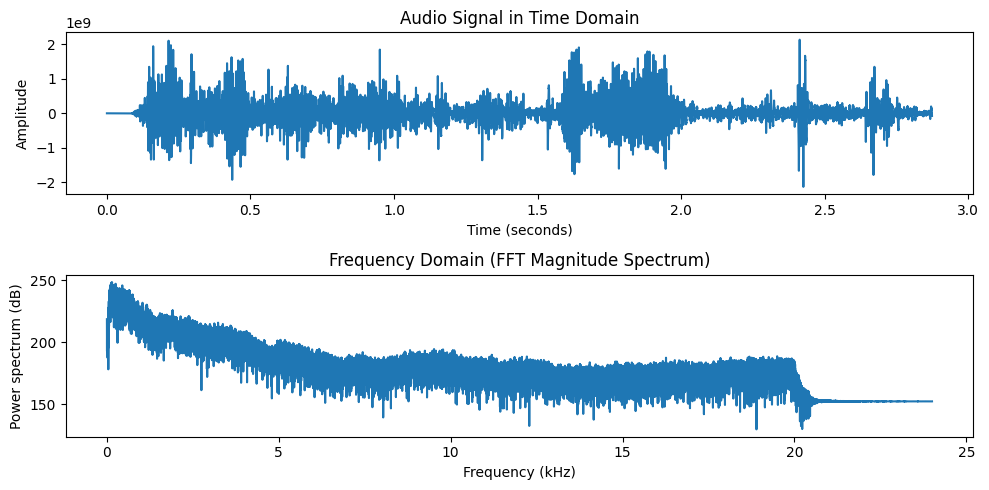

In [6]:
input_file = "./data/noise/audio_1.wav"
visualize_audio_fft(input_file)


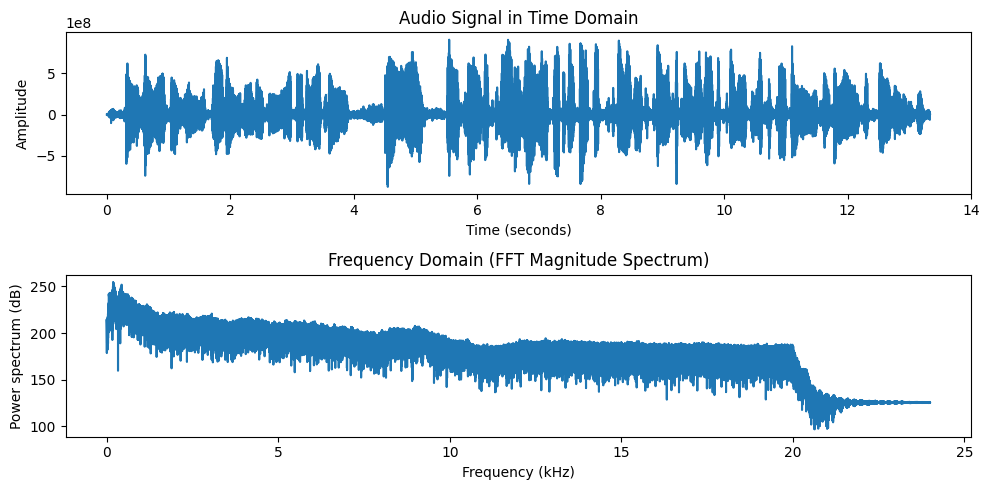

In [7]:
input_file = "./data/clean/audio_1.wav"
visualize_audio_fft(input_file)


In [3]:
import matplotlib.pyplot as plt
from scipy.io import wavfile

def plot_spectrogram(filename):
    sample_rate, data = wavfile.read(filename)
    
    # If stereo, grab one channel
    if len(data.shape) > 1:
        data = data[:, 0]

    plt.figure(figsize=(12, 6))
    # NFFT is the window size (number of points in each FFT)
    # noverlap is how much the windows overlap to stay smooth
    plt.specgram(data, Fs=sample_rate, NFFT=1024, noverlap=512, cmap='magma')
    
    plt.title(f'Spectrogram of {filename}')
    plt.ylabel('Frequency [Hz]')
    plt.xlabel('Time [sec]')
    plt.colorbar(label='Intensity [dB]')
    plt.ylim(0, 8000) # Speech is mostly below 8kHz
    plt.show()

c:\Users\USER\miniconda3\envs\fft\Lib\site-packages\matplotlib\axes\_axes.py:8283: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


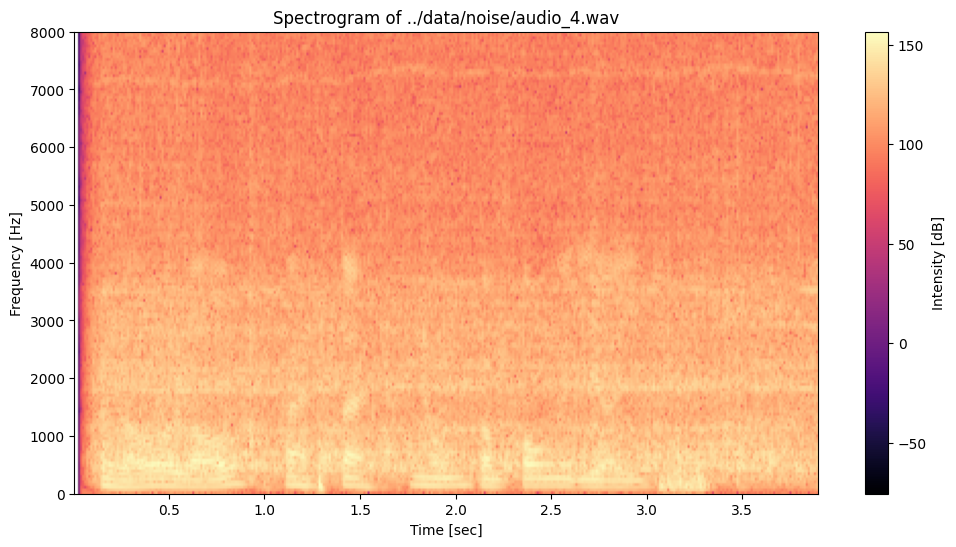

: 

In [ ]:
input_file = "../data/noise/audio_4.wav"
plot_spectrogram(input_file)

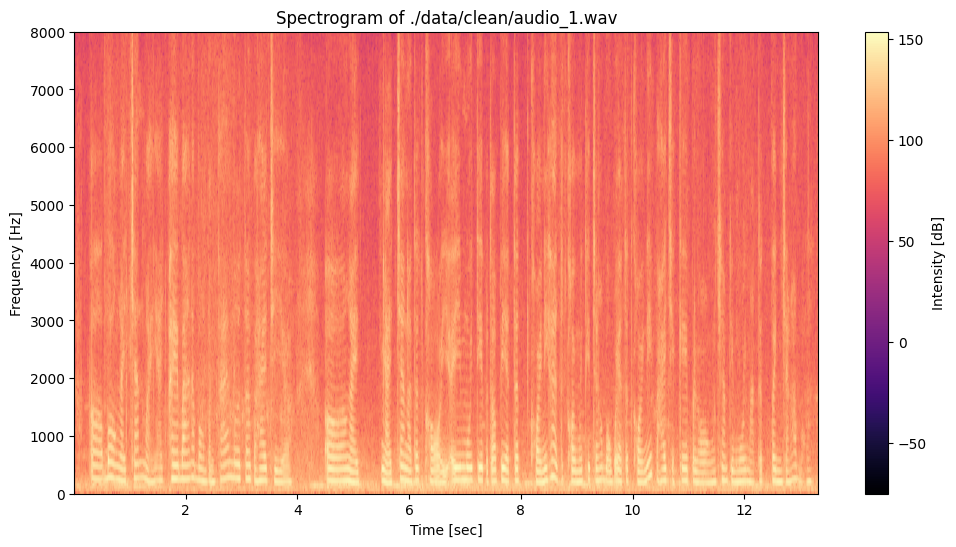

In [11]:
input_file = "./data/clean/audio_1.wav"
plot_spectrogram(input_file)


. Interpreting the Intensity (The Color Bar)The scale on the right (from $-50$ to $+150\text{ dB}$) tells you the volume of specific frequencies:Bright Yellow/White: Very loud (the core of the voice).  
Dark Purple/Black: Silence.  
Red/Orange: Background hum or static

In [ ]:
import numpy as np
import noisereduce as nr # You may need to pip install noisereduce
from scipy.io import wavfile

def aggressive_denoise(filename, output_name):
    # 1. Load the data
    rate, data = wavfile.read(filename)
    
    # 2. Perform the reduction
    # stationary=False allows the algorithm to adjust as the noise changes
    reduced_noise = nr.reduce_noise(y=data, sr=rate, stationary=False, prop_decrease=1.0)
    
    # 3. Normalization (to prevent that static/clipping you felt earlier)
    reduced_noise = reduced_noise.astype(np.float32)
    if np.max(np.abs(reduced_noise)) > 0:
        reduced_noise = reduced_noise / np.max(np.abs(reduced_noise))
    
    # 4. Save
    wavfile.write(output_name, rate, (reduced_noise * 32767).astype(np.int16))
    print("Aggressive denoising complete.")

# aggressive_denoise('audio_4.wav', 'final_clean.wav')